In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/fatigue_project
!ls

/content/drive/MyDrive/fatigue_project
data  download_data.py	fatigue_detection_ml.py  outputs  __pycache__


In [ ]:
!pip install -q xgboost librosa soundfile joblib


In [ ]:
!python download_data.py

✓ Data already present in data/RAVDESS — skipping download.



[Stage 1] Loading RAVDESS metadata...
  Found 1440 .wav files in data/RAVDESS
  Loaded 1440 clips across 24 speakers.
  Label distribution:
label
alert           864
fatigued        384
mild_fatigue    192

  Generating dataset overview plots...


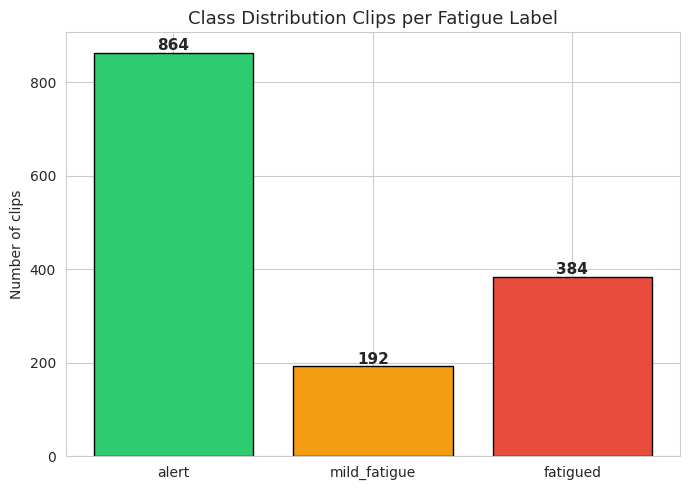

saved outputs/plots/01_label_distribution.png


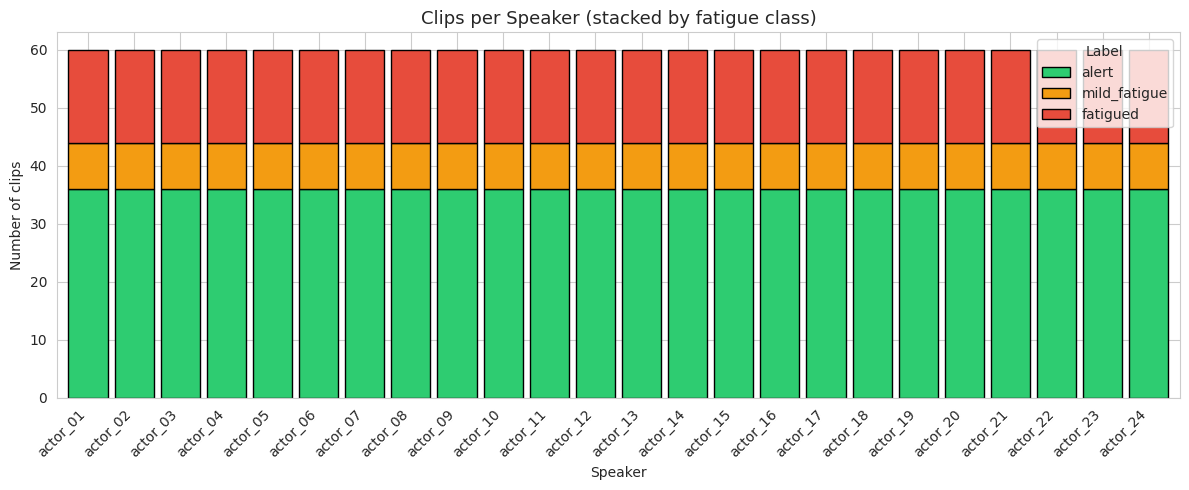

saved outputs/plots/02_speaker_distribution.png


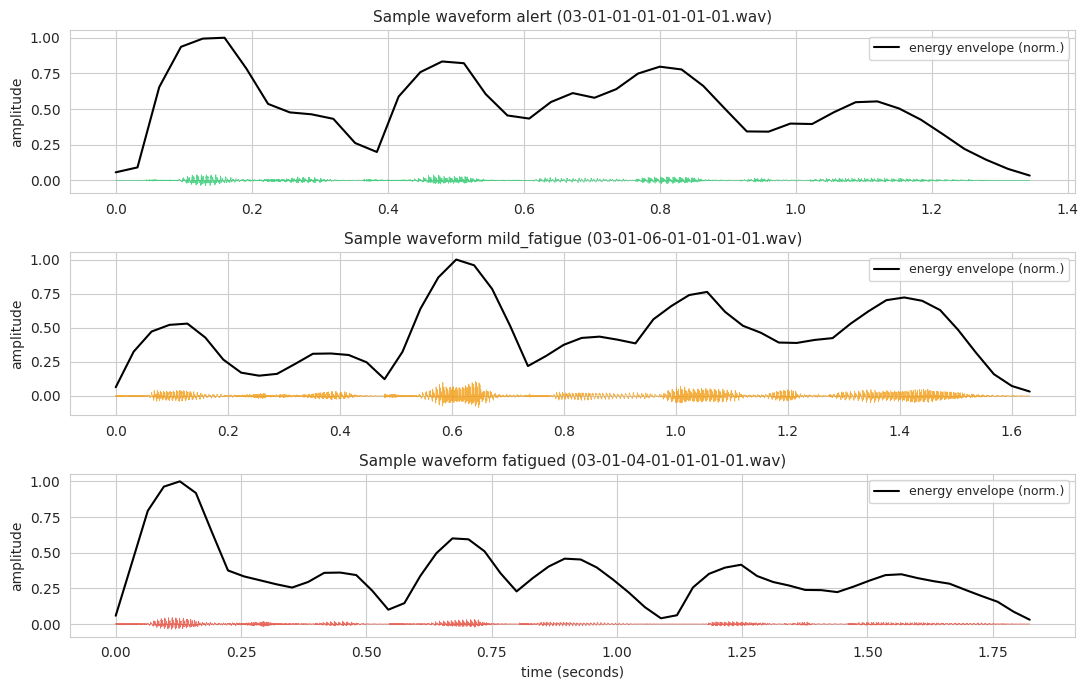

saved outputs/plots/03_sample_waveform.png

[Stage 2] Extracting features (this takes a few minutes)...
  Loading cached features from outputs/features_cache.csv
  Feature matrix: (1440, 84)

  Generating feature distribution plots...


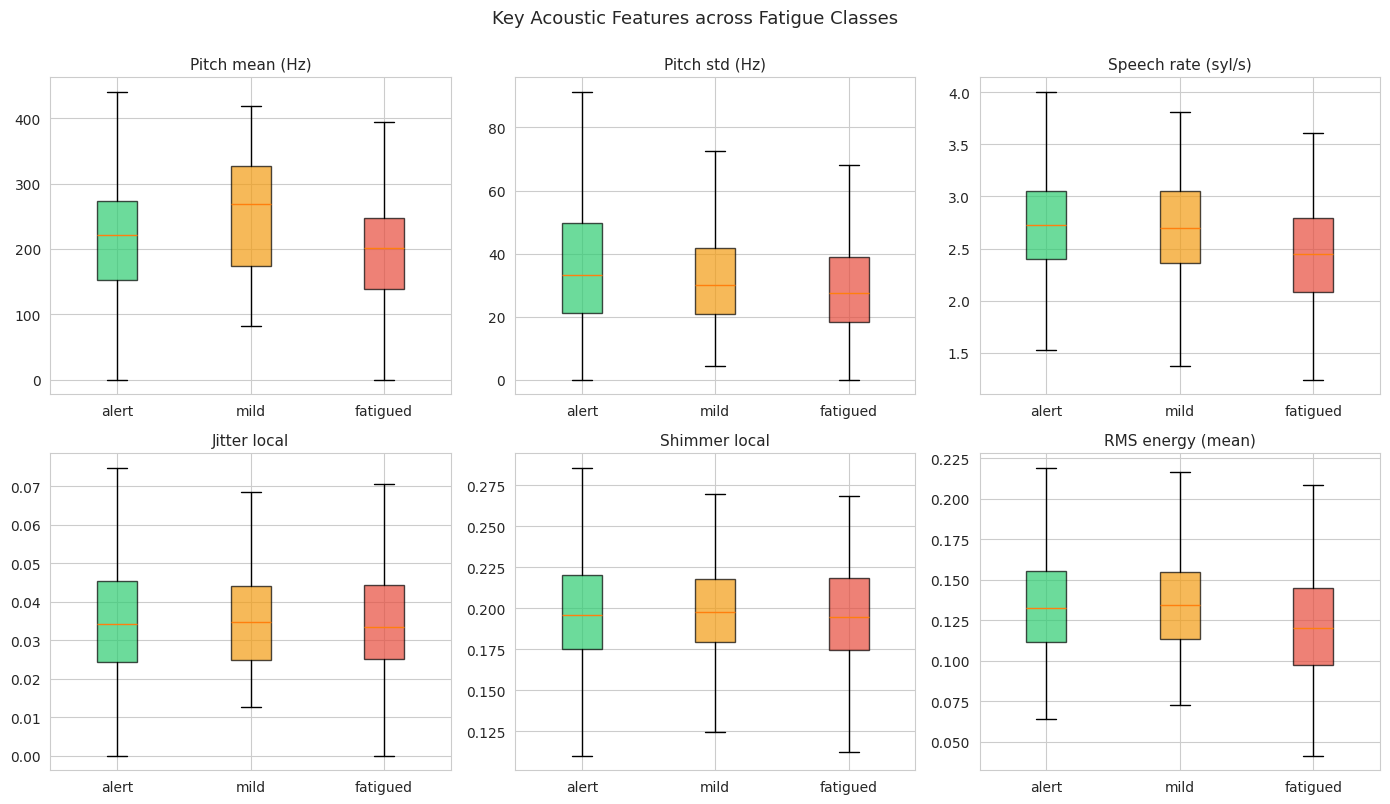

saved outputs/plots/04_feature_boxplots.png

[Stage 3] Computing personal baselines (rested voice per speaker)...
  Built baselines for 24 speakers.


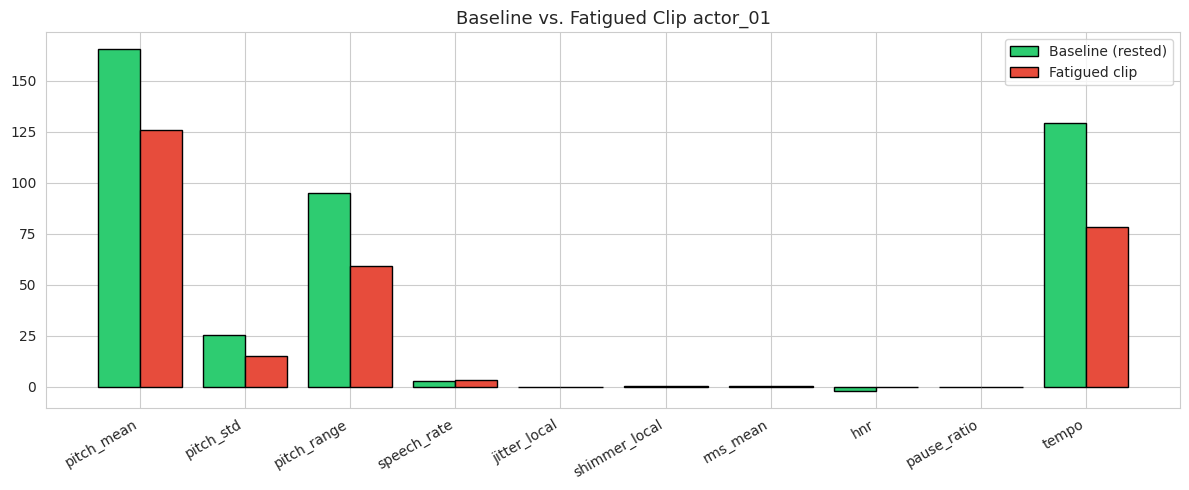

saved outputs/plots/05_baseline_vs_fatigued.png

[Stage 3b] Building delta feature dataset...
  X shape: (1440, 80),  y distribution: [864 192 384]

  Generating delta feature plots...


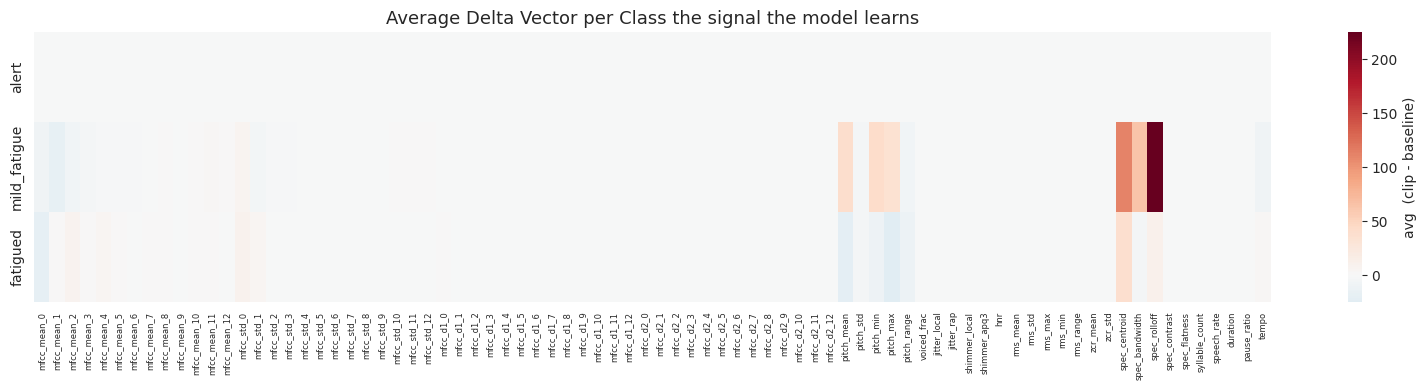

saved outputs/plots/06_delta_feature_heatmap.png


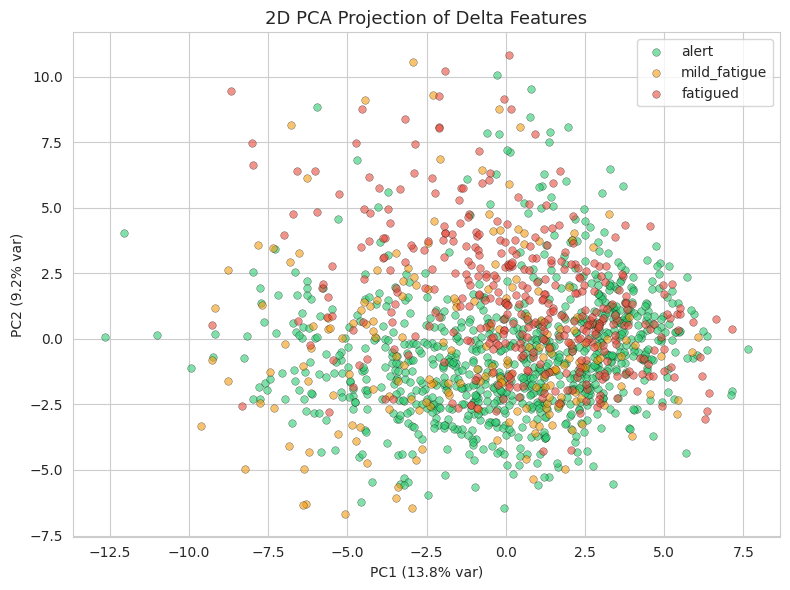

saved outputs/plots/07_pca_2d_deltas.png

[Stage 4] Training models on DELTA features...

---- Training RandomForest ----
  F1 (macro)            : 0.598
  Recall (fatigued class): 0.468
  Classification report:
              precision    recall  f1-score   support

       alert       0.71      0.99      0.83       173
mild_fatigue       1.00      0.21      0.35        38
    fatigued       0.92      0.47      0.62        77

    accuracy                           0.75       288
   macro avg       0.88      0.56      0.60       288
weighted avg       0.80      0.75      0.71       288


---- Training SVM ----
  F1 (macro)            : 0.767
  Recall (fatigued class): 0.753
  Classification report:
              precision    recall  f1-score   support

       alert       0.84      0.88      0.86       173
mild_fatigue       0.73      0.63      0.68        38
    fatigued       0.77      0.75      0.76        77

    accuracy                           0.81       288
   macro avg       0.

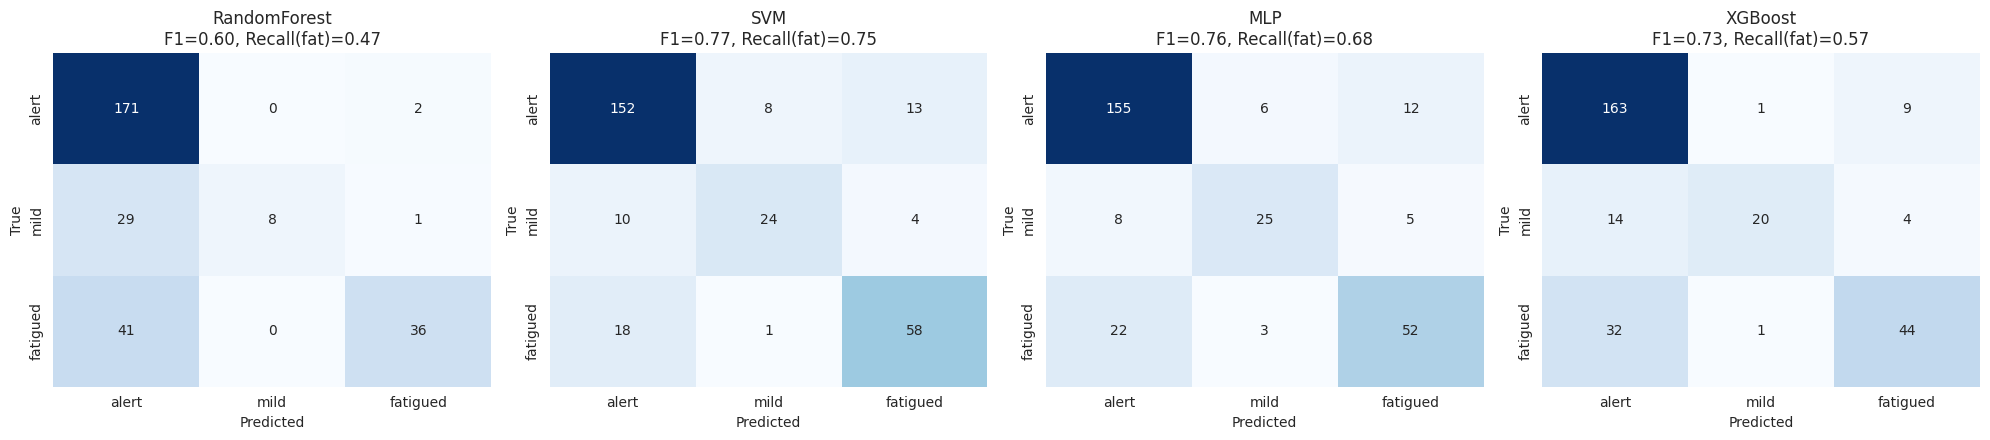

saved outputs/plots/08_confusion_matrices.png


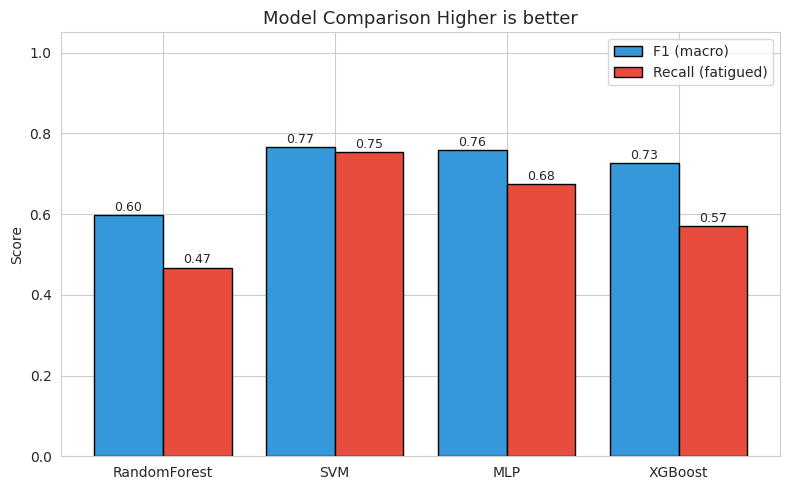

saved outputs/plots/09_model_comparison.png
    (skipped  SVM has no feature_importances_)

[Stage 6] Saving artifacts...
  Saved model + scaler + baselines to outputs/
  Saved 10 plots to outputs/plots/

[Stage 7] Demo inference on one random clip:
  File      : 03-01-07-02-01-01-20.wav
  Speaker   : actor_20
  True label: fatigued
  Predicted : {'fatigue_score': 0.942, 'status': 'fatigued', 'probabilities': {'alert': 0.047, 'mild_fatigue': 0.022, 'fatigued': 0.931}}

 Pipeline finished. You can now call predict_fatigue() on new .wav files.
  Output per check-in: fatigue_score ∈ [0,1], status label, and class probabilities.


<Figure size 640x480 with 0 Axes>

In [ ]:
%run fatigue_detection_ml.py --data_dir data/RAVDESS

In [ ]:
import joblib
import sys
sys.path.append('/content/drive/MyDrive/fatigue_project')
from fatigue_detection_ml import predict_fatigue

model     = joblib.load('outputs/fatigue_model.pkl')
scaler    = joblib.load('outputs/scaler.pkl')
baselines = joblib.load('outputs/baselines.pkl')

result = predict_fatigue(
    wav_path   = 'data/RAVDESS/Actor_05/03-01-04-01-01-01-05.wav',
    speaker_id = 'actor_05',
    model      = model,
    scaler     = scaler,
    baselines  = baselines,
)
print(result)

{'fatigue_score': 0.939, 'status': 'fatigued', 'probabilities': {'alert': 0.056, 'mild_fatigue': 0.009, 'fatigued': 0.935}}
